# Single Event 2D Parameter Scans
## Analyzing combined_product_loss sensitivity to all parameter pairs for one event

In [1]:
import sys
sys.path.append('..')

from tools.geometry import generate_detector
from tools.utils import load_single_event, save_single_event, generate_random_params, print_particle_params
from tools.simulation import setup_event_simulator
from tools.generate import read_photon_data_from_photonsim

import jax
import jax.numpy as jnp
import time

from jax import jit
from pathlib import Path

from matplotlib import pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

import numpy as np
from functools import partial
import pickle
from tqdm import tqdm
from jax import grad, jit, vmap, value_and_grad
import uproot
from scipy.interpolate import interp1d

## Setup Detector and Constants

In [19]:
# Configuration
default_json_filename = '../config/SK_geom_config.json'
data_file = '../data/water/muon/muon_gun_1050_MeV_100_events_fixed_energy.root'
TEMPERATURE = 0.10  # Fixed temperature
N_SCAN_POINTS = 51  # Number of scan points per parameter dimension
K = 7
Nphot = 5_00_000

# Speed of light in medium
C_MEDIUM = 0.299792/1.33  # speed of light in medium

# Setup detector
detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
detector_radius = detector.S_radius
NUM_DETECTORS = len(detector_points)

# Setup data simulator for generating target events (is_data=True, temperature=0.0)
data_simulator = setup_event_simulator(default_json_filename, Nphot, temperature=0.0, K=20,
                                      is_data=True, is_calibration=False)

# Setup prediction simulator with fixed temperature (is_data=False)
prediction_simulator = setup_event_simulator(default_json_filename, Nphot, TEMPERATURE, max_sensors_per_cell=8, K=K, is_data=False)

print(f"Number of detectors: {NUM_DETECTORS}")
print(f"Speed of light in medium: {C_MEDIUM}")
print(f"Number of scan points per parameter: {N_SCAN_POINTS}")

# Load ROOT file information
with uproot.open(data_file) as file:
    tree = file['OpticalPhotons']
    n_entries = tree.num_entries
print(f"ROOT file has {n_entries} entries")

Number of detectors: 10864
Speed of light in medium: 0.22540751879699247
Number of scan points per parameter: 51
ROOT file has 100 entries


## Load Configuration and Detector Parameters

In [20]:
# Detector parameters
detector_params = (
    jnp.array(50.),           # scatter_length
    jnp.array(0.2),          # reflection_rate
    jnp.array(50.),           # absorption_length
    jnp.array(0.001)         # gumbel_softmax_temp
)

from tools.optimization.optimize import load_optimization_config
config = load_optimization_config('../config/single_ring_optimization_config.json')

# Extract basic configuration
default_json_filename = config['basic_config']['default_json_filename']
data_file = config['basic_config']['data_file']
TEMPERATURE = config['basic_config']['temperature']
K = config['basic_config']['k']
Nphot = config['basic_config']['nphot']
C_MEDIUM = config['basic_config']['c_medium']

# Extract optimization weights
VERTEX_WEIGHT_SCALE = config['optimization_weights']['vertex_weight_scale']
COUNTS_WEIGHT_SCALE = config['optimization_weights']['counts_weight_scale']
ENERGY_WEIGHT_SCALE = config['optimization_weights']['energy_weight_scale']

## Combined Product Loss Function

In [21]:
from tools.optimization.losses import energy_loss, counts_loss, direction_time_loss

@jit
def origin_time_loss(origin, detector_positions, true_times, true_q, t0, photosensor_radius=0.25, c_medium=(0.299792/1.33), percentile_threshold=85., scale_w=1e8):
    """Vertex time loss component"""
    distances = jnp.linalg.norm(detector_positions - origin[None, :], axis=1)
    expected_times = (distances - photosensor_radius)/ c_medium
    time_residuals = true_times - expected_times - t0
    
    w1 = jnp.where(true_q>0., true_q, 0.)

    neg_time_res = jnp.where(time_residuals < 0, jnp.abs(time_residuals), 0.0)

    ultra_rel_term = jnp.sum(jnp.abs(neg_time_res*w1)) / (jnp.sum(w1) + 1e-8)+0.075

    pos_time_res = jnp.where(time_residuals > 0, jnp.abs(time_residuals), 0.0)

    w2 = jnp.where(true_q>0., true_q, 0.)
    
    proximity_term =  jnp.sum(jnp.abs(time_residuals*w2**2)) / (jnp.sum(w2) + 1e-8)+0.075

    total_loss = (ultra_rel_term*proximity_term)
 
    return total_loss

def spherical_to_cartesian(theta, phi):
    """Convert spherical angles to Cartesian direction vector"""
    sin_theta = jnp.sin(theta)
    cos_theta = jnp.cos(theta)
    sin_phi = jnp.sin(phi)
    cos_phi = jnp.cos(phi)
    
    return jnp.array([sin_theta * cos_phi, sin_theta * sin_phi, cos_theta])

@jit
def combined_product_loss(params, hit_detector_positions, observed_times, observed_counts, 
                                    true_data, detector_params, key, 
                                    vertex_weight=VERTEX_WEIGHT_SCALE, counts_weight=COUNTS_WEIGHT_SCALE, 
                                    energy_weight=ENERGY_WEIGHT_SCALE):
    """
    Combined loss function: product of vertex loss, counts loss, and energy loss
    
    Args:
        params: [x, y, z, t0, theta, phi, energy] where theta and phi are spherical direction angles
        vertex_weight: scaling factor for vertex loss contribution
        counts_weight: scaling factor for counts loss contribution  
        energy_weight: scaling factor for energy loss contribution
    """
    position = params[:3]
    t0 = params[3]
    theta = params[4]
    phi = params[5]
    energy = params[6]

    track_params = (energy, position, jnp.array([theta, phi]))
    simulated_data = prediction_simulator(track_params, detector_params, key)
    simulated_counts = simulated_data[0]
    simulated_time = simulated_data[1]
    
    # Calculate individual loss components
    vertex_loss_val = origin_time_loss(position, hit_detector_positions, observed_times, observed_counts, t0, c_medium=C_MEDIUM)
    counts_loss_val = counts_loss(observed_counts, simulated_counts)
    energy_loss_val = energy_loss(simulated_counts, observed_counts)

    direction = spherical_to_cartesian(theta, phi)
    direction_loss_val = direction_time_loss(position, direction, hit_detector_positions, observed_times, observed_counts, \
                                             t0, c_medium=C_MEDIUM, angle_scale_deg=2.0, inv_scale_w=0.05)
    
    combined_loss = jnp.sqrt((vertex_weight * vertex_loss_val + 1e-6) * (counts_weight * counts_loss_val + 1e-6))
    
    return combined_loss

print("Combined product loss function defined")

Combined product loss function defined


## Generate Single Data-Like Event

In [22]:
# Select entry from ROOT file
entry_idx = 2

# Load photon data from ROOT file
photon_data = read_photon_data_from_photonsim(data_file, entry_idx)

# Process photon data
photon_origins = photon_data['photon_origins']
photon_directions = photon_data['photon_directions']
photon_times = photon_data['photon_times']
N = len(photon_origins)

# the number 1_000_000 is hard coded also in _simulation_core
padding_size = max(0, 1_000_000-N)

# Pad the origins array (2D array with shape [N,3])
photon_data['photon_origins'] = jnp.pad(photon_origins, ((0, padding_size), (0, 0)), 
                                    mode='constant', constant_values=0)

# Pad the directions array with a default unit vector [0,0,1]
default_direction = jnp.array([0.0, 0.0, 1.0])
padding_directions = jnp.tile(default_direction, (padding_size, 1))
if padding_size > 0:
    photon_data['photon_directions'] = jnp.concatenate([photon_directions, padding_directions], axis=0)
else:
    photon_data['photon_directions'] = photon_directions

# Pad the times array (1D array with shape [N])
photon_data['photon_times'] = jnp.pad(photon_times, (0, padding_size),
                                      mode='constant', constant_values=0)

photon_data['N'] = N

# Generate random track parameters
key = jax.random.PRNGKey(44)

# Random position within detector bounds (60% of full volume)
fraction = 0.6
r_vert = jax.random.uniform(key, shape=(), minval=0, maxval=detector.r * fraction)
key, _ = jax.random.split(key)
theta_pos = jax.random.uniform(key, shape=(), minval=0, maxval=2*jnp.pi)
key, _ = jax.random.split(key)
z_vert = jax.random.uniform(key, shape=(), minval=-detector.H/2 * fraction, 
                           maxval=detector.H/2 * fraction)
true_position = jnp.array([r_vert * jnp.cos(theta_pos), r_vert * jnp.sin(theta_pos), z_vert])

# Random direction
key, _ = jax.random.split(key)
phi = jax.random.uniform(key, shape=(), minval=0, maxval=2*jnp.pi)
key, _ = jax.random.split(key)
cos_theta = jax.random.uniform(key, shape=(), minval=-1, maxval=1)
sin_theta = jnp.sqrt(1 - cos_theta**2)
true_direction = jnp.array([sin_theta * jnp.cos(phi), sin_theta * jnp.sin(phi), cos_theta])

# Use energy from ROOT file
true_energy = photon_data['energy']  # Fixed energy

# Create particle parameters tuple
true_params = (true_energy, true_position, true_direction)

# Generate data-like event
key, _ = jax.random.split(key)
true_data = jax.lax.stop_gradient(data_simulator(true_params, detector_params, key, photon_data))

# Convert direction to spherical coordinates
from tools.optimization.utils.functions import cartesian_to_spherical
true_theta, true_phi = cartesian_to_spherical(true_direction)

# Use t0=0 as default
true_t0 = 0.0

print(f"\nGenerated single event:")
print(f"  Energy: {true_energy:.2f} MeV")
print(f"  Position: [{true_position[0]:.2f}, {true_position[1]:.2f}, {true_position[2]:.2f}] m")
print(f"  Direction (Cartesian): [{true_direction[0]:.3f}, {true_direction[1]:.3f}, {true_direction[2]:.3f}]")
print(f"  Direction (Spherical): theta={true_theta:.3f} rad, phi={true_phi:.3f} rad")
print(f"  t0: {true_t0:.2f} ns")

# Count hit detectors
hit_counts, hit_times = true_data
n_hit = jnp.sum(hit_counts > -1)
print(f"  Hit detectors: {n_hit}")

# Extract hit information
hit_mask = hit_counts > -1
hit_detector_positions = detector_points[hit_mask]
observed_times = hit_times[hit_mask]
observed_charge = hit_counts[hit_mask]


Generated single event:
  Energy: 1050.00 MeV
  Position: [-2.36, -6.82, 10.18] m
  Direction (Cartesian): [-0.367, 0.211, 0.906]
  Direction (Spherical): theta=0.437 rad, phi=2.619 rad
  t0: 0.00 ns
  Hit detectors: 10864


## 2D Parameter Scan Function

In [23]:
def perform_2d_parameter_scan(true_params, true_data, key, param1_name, param1_idx, param1_range,
                             param2_name, param2_idx, param2_range, true_param_values, 
                             use_relative=True, verbose=False):
    """
    Perform 2D scan over two parameters using combined product loss function

    Args:
        true_params: (energy, position, direction) tuple
        true_data: target data-like event (hit_counts, hit_times)
        key: JAX random key
        param1_name: name of first parameter being scanned
        param1_idx: index in params array [x, y, z, t0, theta, phi, energy]
        param1_range: range to scan for param1 (relative ± or absolute range)
        param2_name: name of second parameter being scanned
        param2_idx: index in params array
        param2_range: range to scan for param2 (relative ± or absolute range)
        true_param_values: [x, y, z, t0, theta, phi, energy] array of true values
        use_relative: if True, ranges are relative to true values; if False, absolute
        verbose: if True, print detailed timing information

    Returns:
        dict with param values, losses, gradients, and timing info
    """
    t_start_total = time.time()

    # Setup phase
    t_start_setup = time.time()

    # Extract hit times from true_data
    hit_counts, hit_times = true_data

    # Filter for detectors that were hit
    hit_mask = hit_counts > -1
    hit_detector_positions = detector_points[hit_mask]
    observed_times = hit_times[hit_mask]
    observed_charge = hit_counts[hit_mask]

    # Generate scan points for both parameters
    true_value1 = true_param_values[param1_idx]
    true_value2 = true_param_values[param2_idx]
    
    if use_relative:
        param1_values = jnp.linspace(true_value1 - param1_range, true_value1 + param1_range, N_SCAN_POINTS)
        param2_values = jnp.linspace(true_value2 - param2_range, true_value2 + param2_range, N_SCAN_POINTS)
    else:
        param1_values = jnp.linspace(param1_range[0], param1_range[1], N_SCAN_POINTS)
        param2_values = jnp.linspace(param2_range[0], param2_range[1], N_SCAN_POINTS)

    t_setup = time.time() - t_start_setup

    # Define loss and gradient function
    def loss_and_grad_fn(params):
        def loss_fn(p):
            # Need a random key for simulator in combined_product_loss
            loss_key = jax.random.PRNGKey(42)  # Fixed key for consistency
            return combined_product_loss(p, hit_detector_positions, observed_times, observed_charge,
                                        true_data, detector_params, loss_key)
        return value_and_grad(loss_fn)(params)

    # Warmup (JIT compilation) - run once before timing
    t_start_warmup = time.time()
    warmup_params = jnp.array(true_param_values)
    _ = loss_and_grad_fn(warmup_params)
    jax.block_until_ready(_)  # Wait for computation to complete
    t_warmup = time.time() - t_start_warmup

    # 2D Scan loop
    losses = jnp.zeros((N_SCAN_POINTS, N_SCAN_POINTS))
    gradients = jnp.zeros((N_SCAN_POINTS, N_SCAN_POINTS, 2))  # Store gradients for both params
    
    t_start_scan = time.time()
    for i, param1_val in enumerate(tqdm(param1_values, desc=f"Scanning {param1_name}")):
        for j, param2_val in enumerate(param2_values):
            # Create parameter vector with modified parameters
            params = jnp.array(true_param_values)
            params = params.at[param1_idx].set(param1_val)
            params = params.at[param2_idx].set(param2_val)

            # Calculate loss and gradient
            loss, grad_val = loss_and_grad_fn(params)
            jax.block_until_ready((loss, grad_val))  # Ensure computation completes

            # Extract gradients for both parameters
            param1_gradient = grad_val[param1_idx]
            param2_gradient = grad_val[param2_idx]

            losses = losses.at[i, j].set(loss)
            gradients = gradients.at[i, j].set(jnp.array([param1_gradient, param2_gradient]))

    t_scan = time.time() - t_start_scan
    t_total = time.time() - t_start_total

    # Timing statistics
    timing_info = {
        'total_time': t_total,
        'setup_time': t_setup,
        'warmup_time': t_warmup,
        'scan_time': t_scan,
        'avg_per_point': t_scan / (N_SCAN_POINTS * N_SCAN_POINTS),
    }

    if verbose:
        print(f"\n  ({param1_name}, {param2_name}) scan timing:")
        print(f"    Total: {timing_info['total_time']:.4f}s")
        print(f"    Per point (avg): {timing_info['avg_per_point']:.4f}s")

    return {
        'param1_name': param1_name,
        'param2_name': param2_name,
        'param1_values': param1_values,
        'param2_values': param2_values,
        'losses': losses,
        'gradients': gradients,
        'true_value1': true_value1,
        'true_value2': true_value2,
        'n_hit_detectors': jnp.sum(hit_mask),
        'timing': timing_info
    }

print("2D parameter scan function defined")

2D parameter scan function defined


## Define Parameter Scan Configurations

In [24]:
# Define true parameter values array: [x, y, z, t0, theta, phi, energy]
true_param_values = [
    float(true_position[0]),  # x
    float(true_position[1]),  # y
    float(true_position[2]),  # z
    float(true_t0),           # t0
    float(true_theta),        # theta
    float(true_phi),          # phi
    float(true_energy)        # energy
]

# Parameter names and scan ranges
param_configs = {
    0: ('X', 0.5),           # ±0.5 m
    1: ('Y', 0.5),           # ±0.5 m
    2: ('Z', 0.5),           # ±0.5 m
    3: ('t0', 5.0),          # ±1.0 ns
    4: ('theta', 0.3),       # ±0.3 rad
    5: ('phi', 0.3),         # ±0.3 rad
    6: ('E', 250.0),         # ±100 MeV
}

# Define all parameter pairs to scan
# Format: (param1_idx, param2_idx)
scan_pairs = [
    # # Position pairs
    # (0, 1),  # (x, y)
    # (0, 2),  # (x, z)
    # (1, 2),  # (y, z)
    # # Position-time
    # (0, 3),  # (x, t0)
    # (1, 3),  # (y, t0)
    # (2, 3),  # (z, t0)
    # # Position-direction (theta)
    # (0, 4),  # (x, theta)
    # (1, 4),  # (y, theta)
    # (2, 4),  # (z, theta)
    # # Position-direction (phi)
    # (0, 5),  # (x, phi)
    # (1, 5),  # (y, phi)
    # (2, 5),  # (z, phi)
    # # Position-energy
    # (0, 6),  # (x, E)
    # (1, 6),  # (y, E)
    # (2, 6),  # (z, E)
    # # Time-direction
    # (3, 4),  # (t0, theta)
    # (3, 5),  # (t0, phi)
    # # Time-energy
    (3, 6),  # (t0, E)
    # # Direction pairs
    # (4, 5),  # (theta, phi)
    # # Direction-energy
    # (4, 6),  # (theta, E)
    # (5, 6),  # (phi, E)
]

print(f"Total number of 2D scans to perform: {len(scan_pairs)}")
print(f"Total number of loss evaluations: {len(scan_pairs) * N_SCAN_POINTS * N_SCAN_POINTS}")

Total number of 2D scans to perform: 1
Total number of loss evaluations: 2601


## Perform All 2D Parameter Scans

In [25]:
# Perform all 2D scans
scan_results_2d = []

print(f"\nPerforming {len(scan_pairs)} 2D parameter scans...")
print("=" * 80)

for i, (param1_idx, param2_idx) in enumerate(scan_pairs):
    param1_name, param1_range = param_configs[param1_idx]
    param2_name, param2_range = param_configs[param2_idx]
    
    print(f"\n[{i+1}/{len(scan_pairs)}] Scanning parameters: ({param1_name}, {param2_name})")
    
    key, _ = jax.random.split(key)
    result = perform_2d_parameter_scan(
        true_params, 
        true_data, 
        key, 
        param1_name, 
        param1_idx, 
        param1_range,
        param2_name,
        param2_idx,
        param2_range,
        true_param_values,
        use_relative=True,
        verbose=True
    )
    
    scan_results_2d.append(result)

print("\n" + "=" * 80)
print("All 2D parameter scans completed!")


Performing 1 2D parameter scans...

[1/1] Scanning parameters: (t0, E)


Scanning t0: 100%|██████████| 51/51 [08:32<00:00, 10.04s/it]


  (t0, E) scan timing:
    Total: 574.7532s
    Per point (avg): 0.1969s

All 2D parameter scans completed!


## Save 2D Scan Results to Pickle

In [26]:
# Create output directory if it doesn't exist
output_dir = Path('../output')
output_dir.mkdir(parents=True, exist_ok=True)

# Prepare results dictionary
all_results_2d = {
    'c_medium': C_MEDIUM,
    'temperature': TEMPERATURE,
    'n_scan_points': N_SCAN_POINTS,
    'true_energy': float(true_energy),
    'true_position': [float(x) for x in true_position],
    'true_direction': [float(x) for x in true_direction],
    'true_theta': float(true_theta),
    'true_phi': float(true_phi),
    'true_t0': float(true_t0),
    'n_hit_detectors': int(n_hit),
    'scans_2d': []
}

# Convert scan results to serializable format
for result in scan_results_2d:
    scan_data = {
        'param1_name': result['param1_name'],
        'param2_name': result['param2_name'],
        'param1_values': np.array(result['param1_values']),
        'param2_values': np.array(result['param2_values']),
        'losses': np.array(result['losses']),
        'gradients': np.array(result['gradients']),
        'true_value1': float(result['true_value1']),
        'true_value2': float(result['true_value2']),
        'timing': result['timing']
    }
    all_results_2d['scans_2d'].append(scan_data)

# Save results to pickle file
output_file = output_dir / 'TEST_single_event_2d_parameter_scans.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(all_results_2d, f)

print(f"\n2D scan results saved to {output_file}")
print(f"File size: {output_file.stat().st_size / 1e6:.2f} MB")


2D scan results saved to ../output/TEST_single_event_2d_parameter_scans.pkl
File size: 0.03 MB


## Load Results and Create Visualizations

In [101]:
output_file = output_dir / 'single_event_2d_parameter_scans.pkl'

# Load results from pickle file
with open(output_file, 'rb') as f:
    loaded_results = pickle.load(f)

print(f"Loaded {len(loaded_results['scans_2d'])} 2D scans from file")
print(f"Event details:")
print(f"  Energy: {loaded_results['true_energy']:.2f} MeV")
print(f"  Position: {loaded_results['true_position']}")
print(f"  Direction (spherical): theta={loaded_results['true_theta']:.3f}, phi={loaded_results['true_phi']:.3f}")
print(f"  Hit detectors: {loaded_results['n_hit_detectors']}")

Loaded 21 2D scans from file
Event details:
  Energy: 1050.00 MeV
  Position: [-2.3594045639038086, -6.821823596954346, 10.177542686462402]
  Direction (spherical): theta=0.437, phi=2.619
  Hit detectors: 10864


## Visualization Function

In [104]:
def plot_2d_gradient_scan(scan_data, save_fig=True):
    """
    Create a 2D gradient visualization similar to origin_time_loss_2D_gradients.ipynb
    
    Args:
        scan_data: Dictionary containing scan results for one parameter pair
        save_fig: Whether to save the figure
    """
    param1_name = scan_data['param1_name']
    param2_name = scan_data['param2_name']
    param1_values = scan_data['param1_values']
    param2_values = scan_data['param2_values']
    losses = scan_data['losses']
    gradients = scan_data['gradients']
    # if param2_name == 'E':
    #     gradients[:, :, 1] *=100000
    # else:
    #     return

    # if param1_name == 't0':
    #     gradients[:, :, 0] *=500

    if param2_name == 'E':
        #return
    
        A = np.linalg.norm(gradients[:, :, 0])
        B = np.linalg.norm(gradients[:, :, 1])
        
        print(A)
        print(B)
        print("after: \n")
    
        gradients[:, :, 1] *= 50*A/B
    
        A = np.linalg.norm(gradients[:, :, 0])
        B = np.linalg.norm(gradients[:, :, 1])
        
        print(A)
        print(B)
        print("\n")

    elif param1_name == 't0':
        A = np.linalg.norm(gradients[:, :, 0])
        B = np.linalg.norm(gradients[:, :, 1])
        
        print(A)
        print(B)
        print("after: \n")
    
        gradients[:, :, 0] *= 250*A/B
    
        A = np.linalg.norm(gradients[:, :, 0])
        B = np.linalg.norm(gradients[:, :, 1])
        
        print(A)
        print(B)
        print("\n")
    # else:
    #     return
    
        
    # print(gradients[:, :, 1])
    true_value1 = scan_data['true_value1']
    true_value2 = scan_data['true_value2']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot 2D loss surface
    im = ax.imshow(losses.T, extent=[param1_values[0], param1_values[-1],
                                   param2_values[0], param2_values[-1]],
                  origin='lower', aspect='auto', cmap='viridis')
    fig.colorbar(im, ax=ax, label='Loss')
    
    # Create equally spaced coordinate arrays for streamplot
    p1_min, p1_max = float(param1_values[0]), float(param1_values[-1])
    p2_min, p2_max = float(param2_values[0]), float(param2_values[-1])
    n_points_p1 = len(param1_values)
    n_points_p2 = len(param2_values)
    
    # Force equal spacing
    p1 = np.linspace(p1_min, p1_max, n_points_p1)
    p2 = np.linspace(p2_min, p2_max, n_points_p2)
    
    P1, P2 = np.meshgrid(p1, p2)
    
    # Convert gradients to numpy (negative for gradient descent direction)
    U = -1 * np.array(gradients[:, :, 0].T)  # param1 gradient
    V = -1 * np.array(gradients[:, :, 1].T)  # param2 gradient
    
    # Normalize gradients for better visualization
    norm = np.sqrt(U**2 + V**2)
    norm = np.where(norm == 0, 1, norm)
    U_norm = U / norm
    V_norm = V / norm
    
    # Add streamplot on top of loss surface
    strm = ax.streamplot(P1, P2, U_norm, V_norm, 
                        color='white',
                        density=1.0,
                        linewidth=1,
                        arrowsize=1)
    
    # Add marker for true parameter values
    ax.plot(true_value1, true_value2, color='red', marker='*', 
            linewidth=0, markersize=15, label='True Values')
    
    # Find and mark minimum loss position
    min_idx = np.unravel_index(np.argmin(losses), losses.shape)
    min_p1 = param1_values[min_idx[0]]
    min_p2 = param2_values[min_idx[1]]
    # ax.plot(min_p1, min_p2, color='yellow', marker='o', 
    #         linewidth=0, markersize=10, label='Min Loss')
    
    ax.set_xlabel(f'{param1_name}')
    ax.set_ylabel(f'{param2_name}')
    ax.set_title(f'Loss Surface with Gradient Streamlines: {param1_name} vs {param2_name}')
    ax.legend()
    ax.set_xlim(p1_min, p1_max)
    ax.set_ylim(p2_min, p2_max)
    plt.tight_layout()
    
    if save_fig:
        figures_dir = Path('figures')
        figures_dir.mkdir(parents=True, exist_ok=True)
        figname = figures_dir / f'2D_Grad_{param1_name}_{param2_name}.pdf'
        plt.savefig(figname, dpi=300, bbox_inches='tight')
        print(f"Figure saved as: {figname}")
    
    plt.show()
    
    # Print summary
    min_loss = losses[min_idx]
    print(f"\n{param1_name} vs {param2_name}:")
    print(f"  True values: {param1_name}={true_value1:.3f}, {param2_name}={true_value2:.3f}")
    print(f"  Min loss at: {param1_name}={min_p1:.3f}, {param2_name}={min_p2:.3f}")
    print(f"  Min loss value: {min_loss:.6f}")
    print(f"  Errors: Δ{param1_name}={min_p1-true_value1:.3f}, Δ{param2_name}={min_p2-true_value2:.3f}")

print("Visualization function defined")

Visualization function defined


## Generate All 2D Gradient Plots

Generating 2D gradient visualizations...

[1/21] Plotting X vs Y
Figure saved as: figures/2D_Grad_X_Y.pdf


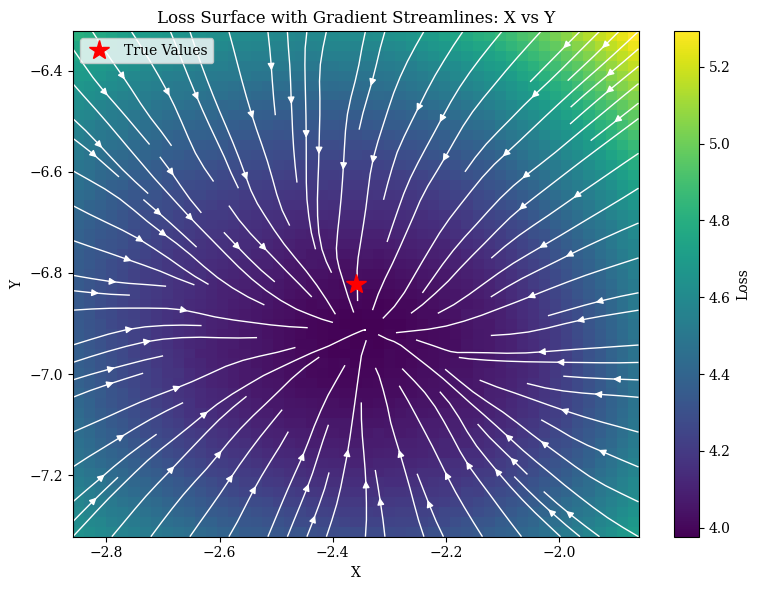


X vs Y:
  True values: X=-2.359, Y=-6.822
  Min loss at: X=-2.359, Y=-6.922
  Min loss value: 3.976549
  Errors: ΔX=0.000, ΔY=-0.100

[2/21] Plotting X vs Z
Figure saved as: figures/2D_Grad_X_Z.pdf


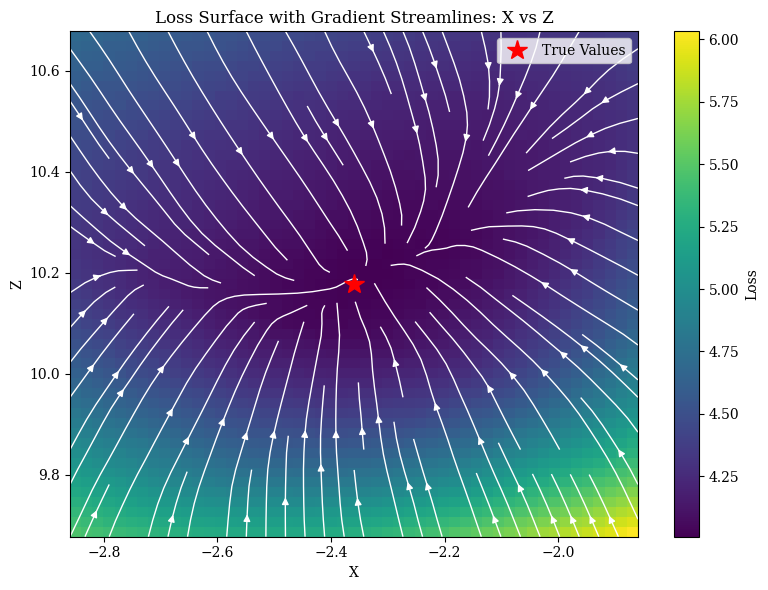


X vs Z:
  True values: X=-2.359, Z=10.178
  Min loss at: X=-2.379, Z=10.178
  Min loss value: 4.008444
  Errors: ΔX=-0.020, ΔZ=0.000

[3/21] Plotting Y vs Z
Figure saved as: figures/2D_Grad_Y_Z.pdf


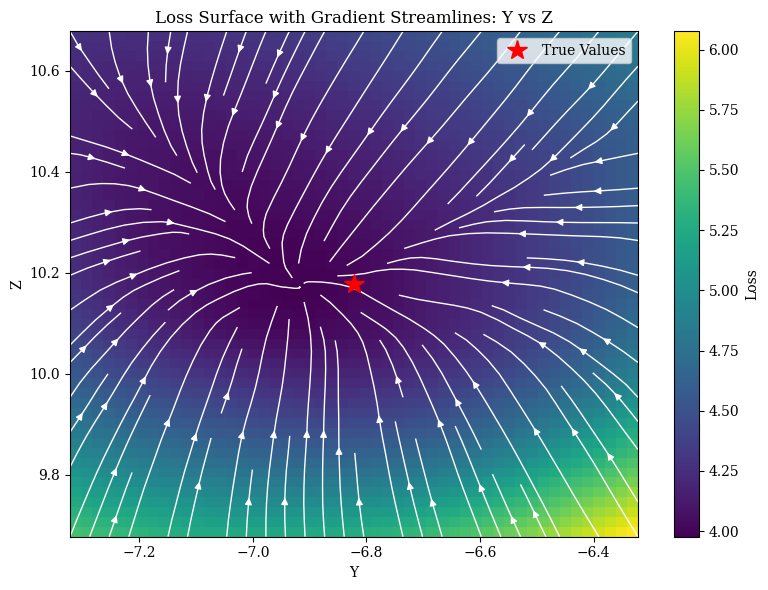


Y vs Z:
  True values: Y=-6.822, Z=10.178
  Min loss at: Y=-6.922, Z=10.178
  Min loss value: 3.976549
  Errors: ΔY=-0.100, ΔZ=0.000

[4/21] Plotting X vs t0
Figure saved as: figures/2D_Grad_X_t0.pdf


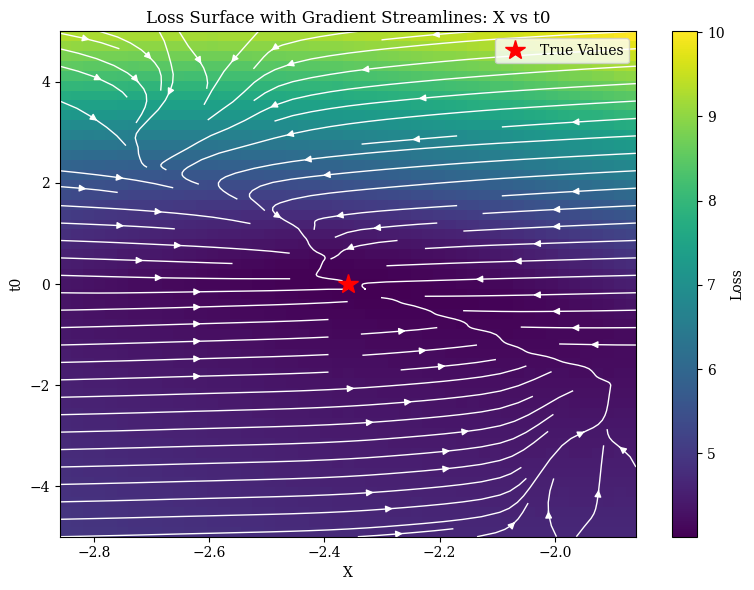


X vs t0:
  True values: X=-2.359, t0=0.000
  Min loss at: X=-2.379, t0=-0.000
  Min loss value: 4.008444
  Errors: ΔX=-0.020, Δt0=-0.000

[5/21] Plotting Y vs t0
Figure saved as: figures/2D_Grad_Y_t0.pdf


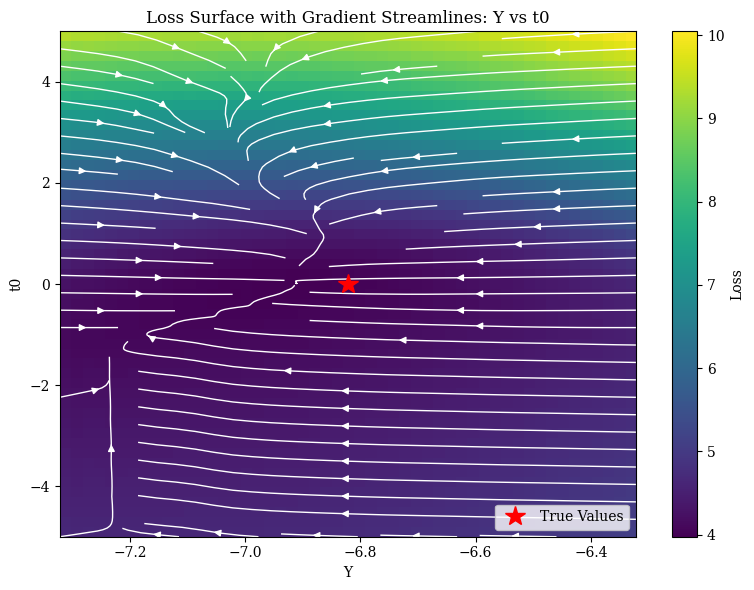


Y vs t0:
  True values: Y=-6.822, t0=0.000
  Min loss at: Y=-6.922, t0=-0.000
  Min loss value: 3.976549
  Errors: ΔY=-0.100, Δt0=-0.000

[6/21] Plotting Z vs t0
Figure saved as: figures/2D_Grad_Z_t0.pdf


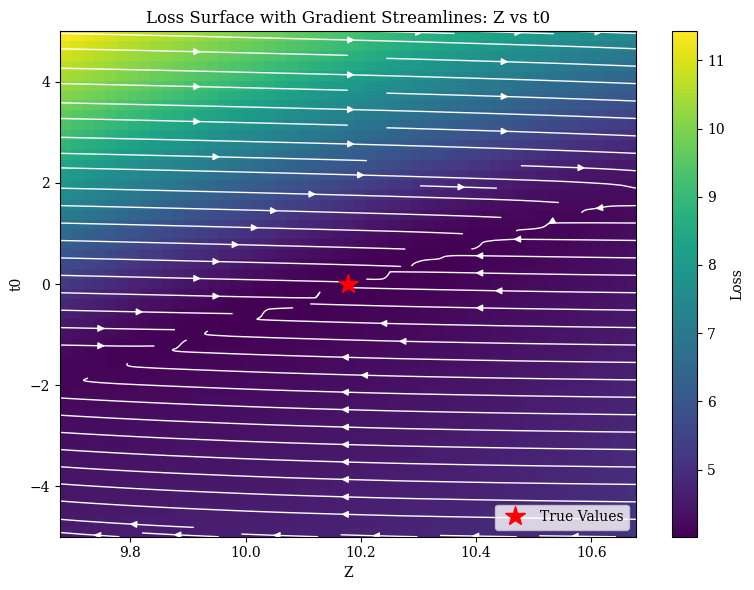


Z vs t0:
  True values: Z=10.178, t0=0.000
  Min loss at: Z=10.238, t0=0.200
  Min loss value: 4.014038
  Errors: ΔZ=0.060, Δt0=0.200

[7/21] Plotting X vs theta
Figure saved as: figures/2D_Grad_X_theta.pdf


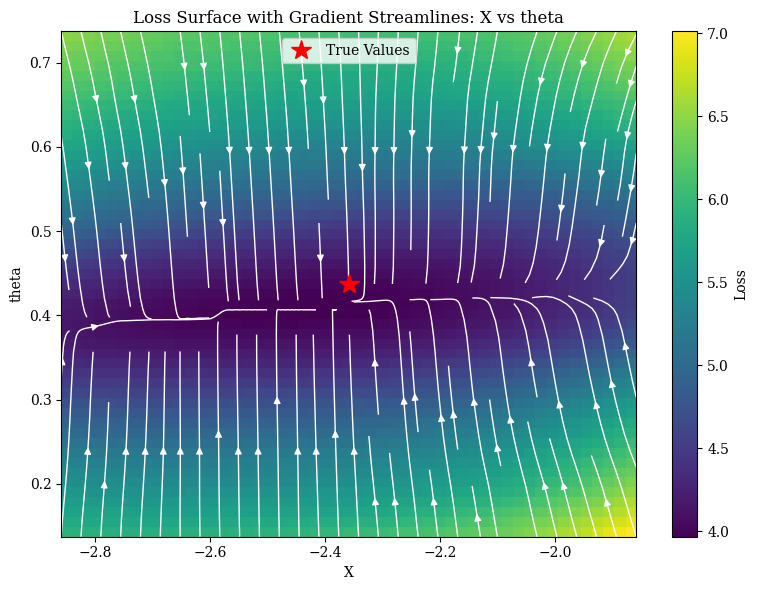


X vs theta:
  True values: X=-2.359, theta=0.437
  Min loss at: X=-2.379, theta=0.413
  Min loss value: 3.967240
  Errors: ΔX=-0.020, Δtheta=-0.024

[8/21] Plotting Y vs theta
Figure saved as: figures/2D_Grad_Y_theta.pdf


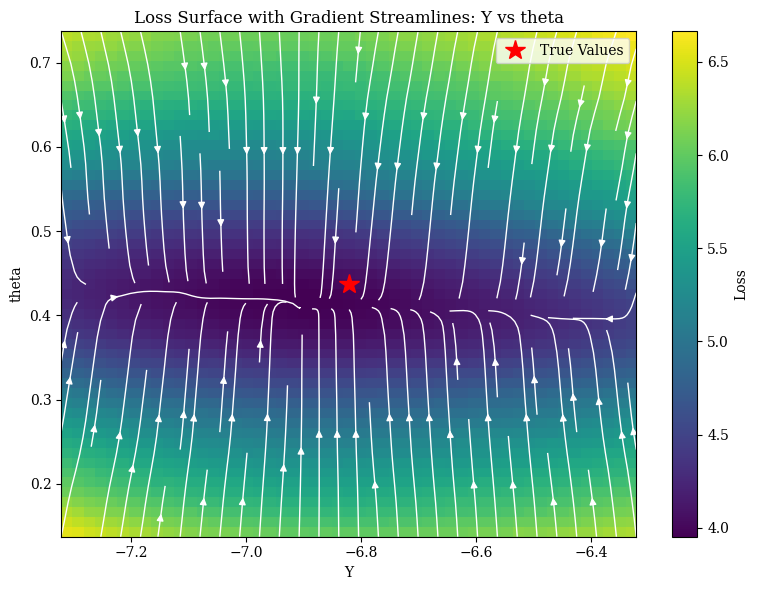


Y vs theta:
  True values: Y=-6.822, theta=0.437
  Min loss at: Y=-6.922, theta=0.425
  Min loss value: 3.952676
  Errors: ΔY=-0.100, Δtheta=-0.012

[9/21] Plotting Z vs theta
Figure saved as: figures/2D_Grad_Z_theta.pdf


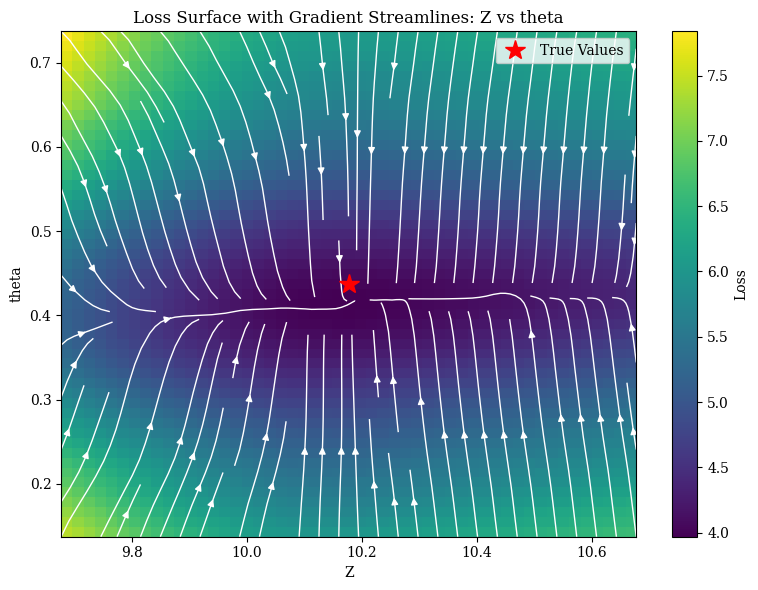


Z vs theta:
  True values: Z=10.178, theta=0.437
  Min loss at: Z=10.178, theta=0.413
  Min loss value: 3.968460
  Errors: ΔZ=0.000, Δtheta=-0.024

[10/21] Plotting X vs phi
Figure saved as: figures/2D_Grad_X_phi.pdf


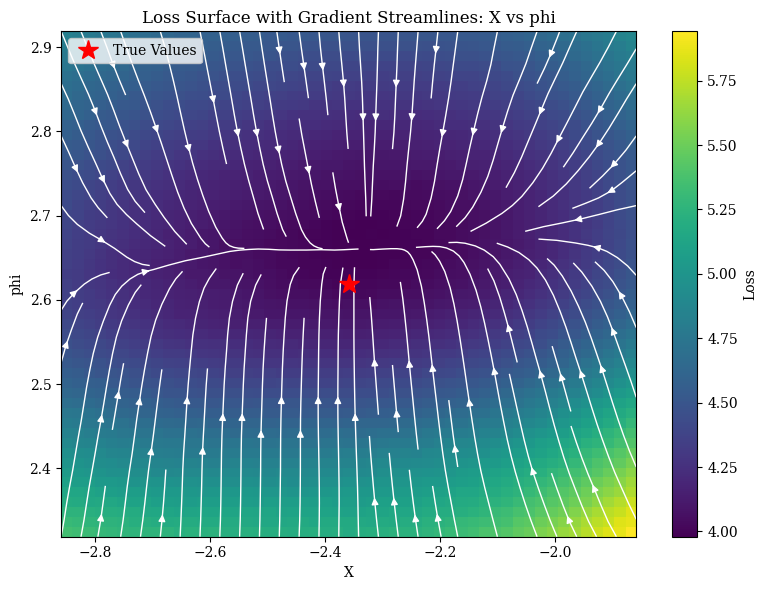


X vs phi:
  True values: X=-2.359, phi=2.619
  Min loss at: X=-2.359, phi=2.655
  Min loss value: 3.979377
  Errors: ΔX=0.000, Δphi=0.036

[11/21] Plotting Y vs phi
Figure saved as: figures/2D_Grad_Y_phi.pdf


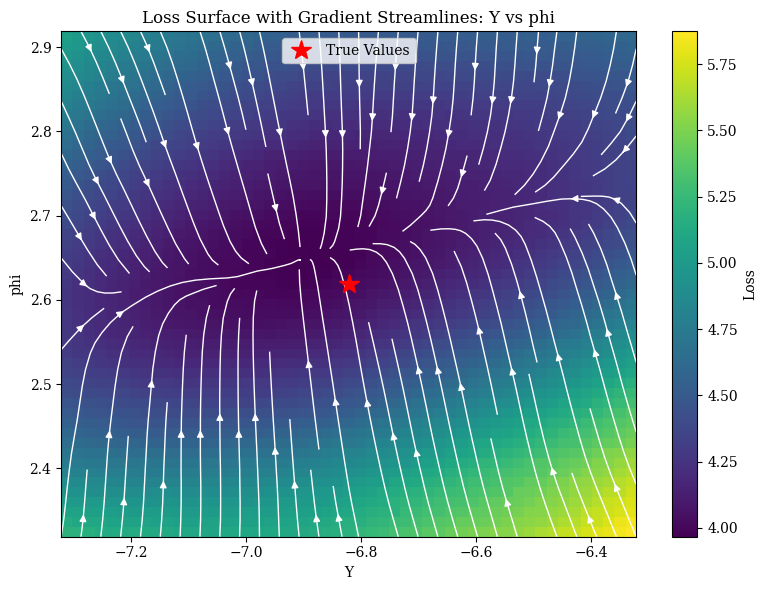


Y vs phi:
  True values: Y=-6.822, phi=2.619
  Min loss at: Y=-6.882, phi=2.643
  Min loss value: 3.967014
  Errors: ΔY=-0.060, Δphi=0.024

[12/21] Plotting Z vs phi
Figure saved as: figures/2D_Grad_Z_phi.pdf


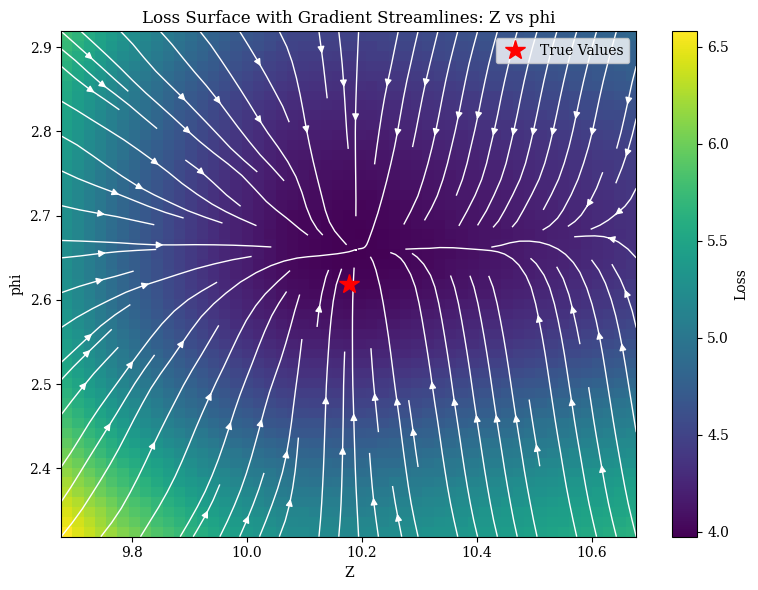


Z vs phi:
  True values: Z=10.178, phi=2.619
  Min loss at: Z=10.198, phi=2.679
  Min loss value: 3.974641
  Errors: ΔZ=0.020, Δphi=0.060

[13/21] Plotting X vs E
51.76882
0.07376848
after: 

51.76882
2588.441


Figure saved as: figures/2D_Grad_X_E.pdf


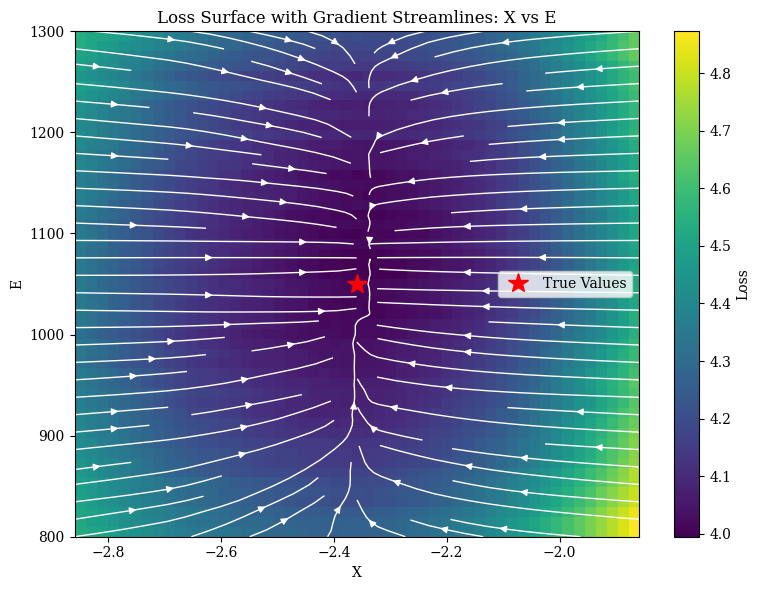


X vs E:
  True values: X=-2.359, E=1050.000
  Min loss at: X=-2.359, E=1070.000
  Min loss value: 3.994934
  Errors: ΔX=0.000, ΔE=20.000

[14/21] Plotting Y vs E
50.1138
0.07318194
after: 

50.1138
2505.69


Figure saved as: figures/2D_Grad_Y_E.pdf


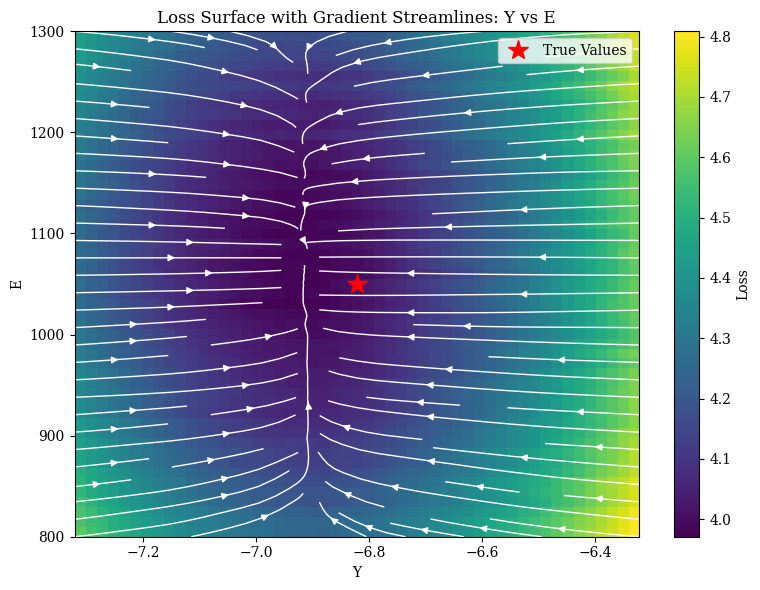


Y vs E:
  True values: Y=-6.822, E=1050.000
  Min loss at: Y=-6.942, E=1030.000
  Min loss value: 3.970953
  Errors: ΔY=-0.120, ΔE=-20.000

[15/21] Plotting Z vs E
110.84439
0.078134
after: 

110.84439
5542.22


Figure saved as: figures/2D_Grad_Z_E.pdf


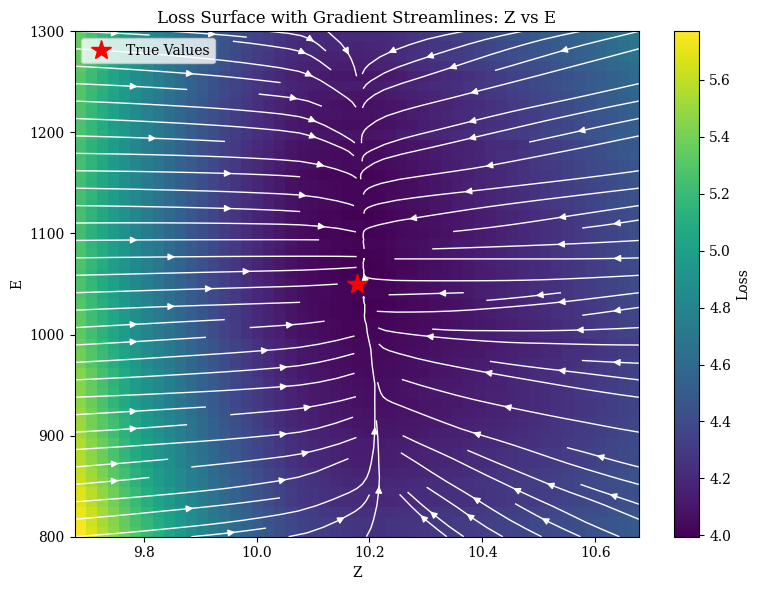


Z vs E:
  True values: Z=10.178, E=1050.000
  Min loss at: Z=10.178, E=1070.000
  Min loss value: 3.994934
  Errors: ΔZ=0.000, ΔE=20.000

[16/21] Plotting t0 vs theta
50.336723
401.0282
after: 

1579.5557
401.0282


Figure saved as: figures/2D_Grad_t0_theta.pdf


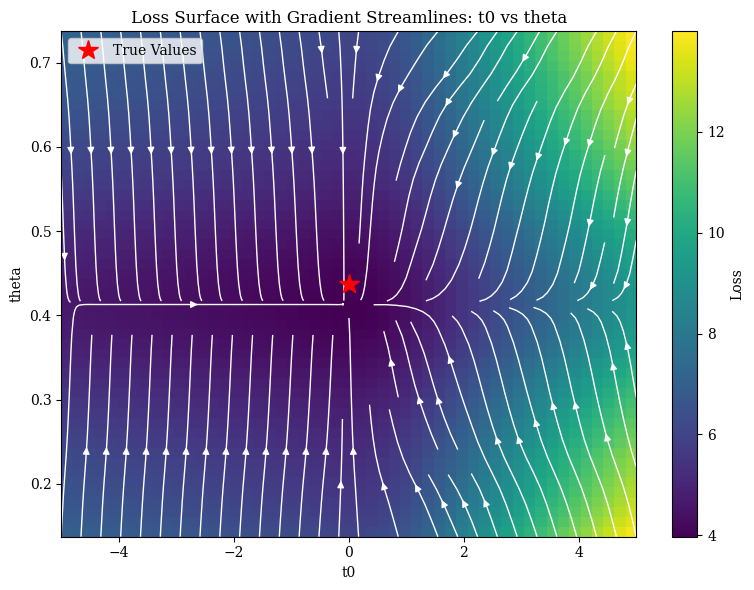


t0 vs theta:
  True values: t0=0.000, theta=0.437
  Min loss at: t0=-0.000, theta=0.413
  Min loss value: 3.968460
  Errors: Δt0=-0.000, Δtheta=-0.024

[17/21] Plotting t0 vs phi
43.81561
192.72481
after: 

2490.3484
192.72481


Figure saved as: figures/2D_Grad_t0_phi.pdf


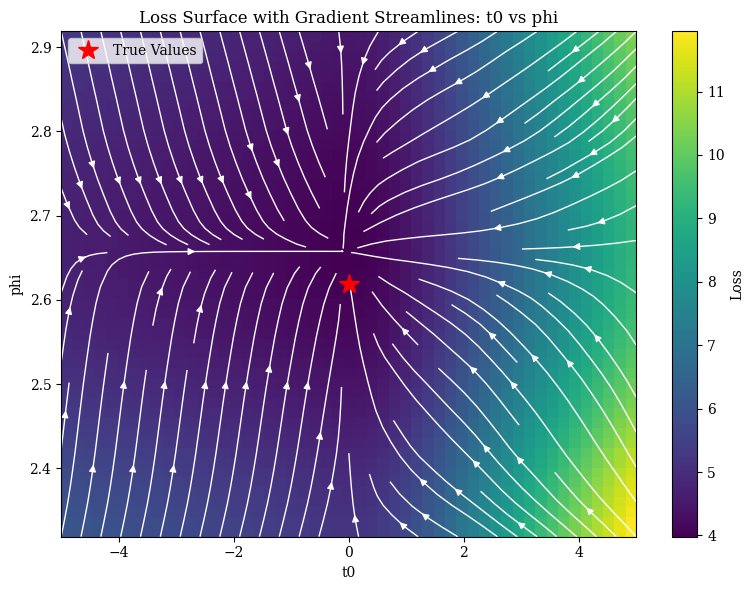


t0 vs phi:
  True values: t0=0.000, phi=2.619
  Min loss at: t0=-0.000, phi=2.655
  Min loss value: 3.979377
  Errors: Δt0=-0.000, Δphi=0.036

[18/21] Plotting t0 vs E
40.862423
0.100177504
after: 

40.862423
2043.1212


Figure saved as: figures/2D_Grad_t0_E.pdf


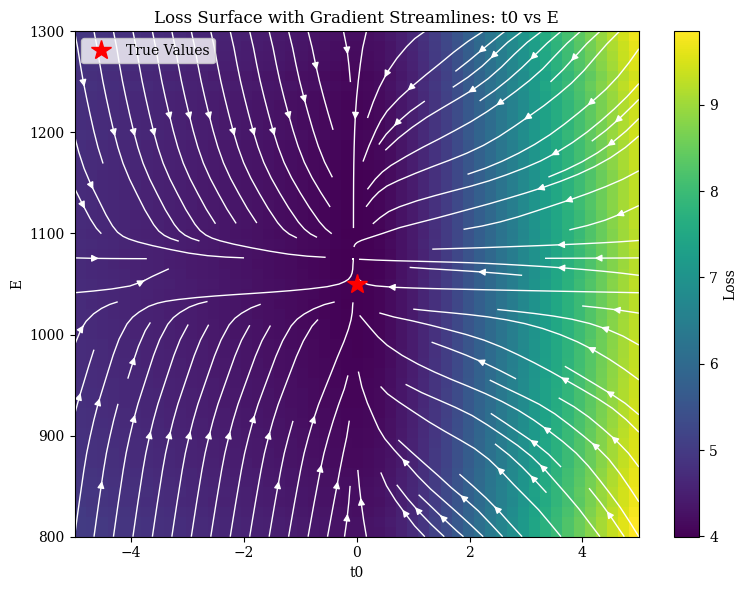


t0 vs E:
  True values: t0=0.000, E=1050.000
  Min loss at: t0=-0.000, E=1070.000
  Min loss value: 3.994934
  Errors: Δt0=-0.000, ΔE=20.000

[19/21] Plotting theta vs phi
Figure saved as: figures/2D_Grad_theta_phi.pdf


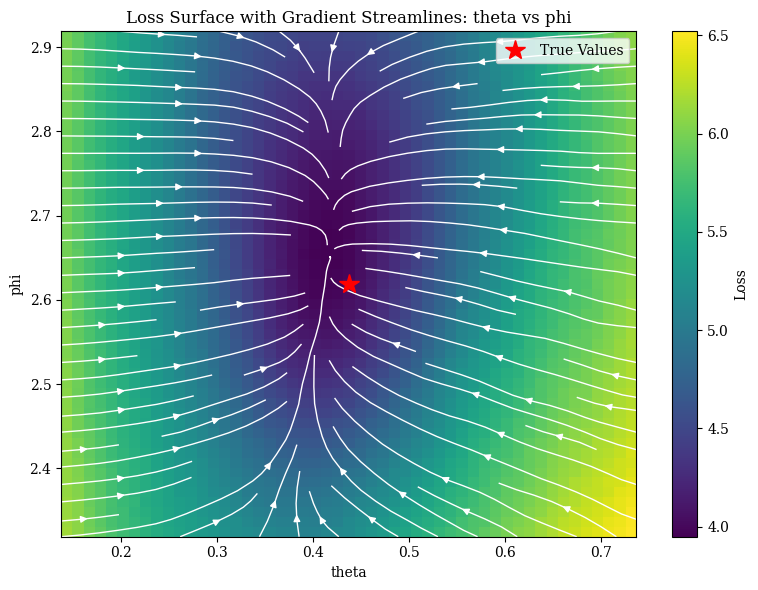


theta vs phi:
  True values: theta=0.437, phi=2.619
  Min loss at: theta=0.413, phi=2.655
  Min loss value: 3.948740
  Errors: Δtheta=-0.024, Δphi=0.036

[20/21] Plotting theta vs E
287.5229
0.05809298
after: 

287.5229
14376.1455


Figure saved as: figures/2D_Grad_theta_E.pdf


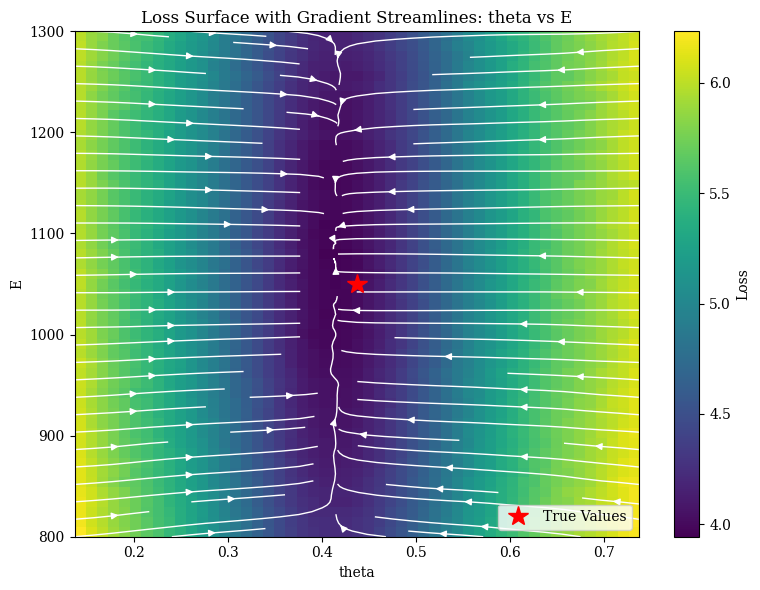


theta vs E:
  True values: theta=0.437, E=1050.000
  Min loss at: theta=0.413, E=1080.000
  Min loss value: 3.942583
  Errors: Δtheta=-0.024, ΔE=30.000

[21/21] Plotting phi vs E
136.23427
0.0662359
after: 

136.23427
6811.7134


Figure saved as: figures/2D_Grad_phi_E.pdf


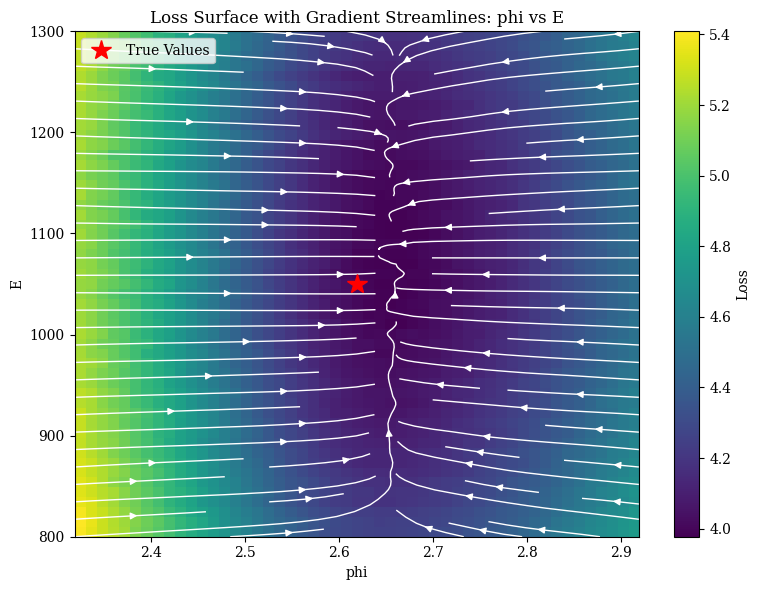


phi vs E:
  True values: phi=2.619, E=1050.000
  Min loss at: phi=2.667, E=1110.000
  Min loss value: 3.976988
  Errors: Δphi=0.048, ΔE=60.000

All visualizations completed!


In [105]:
# Generate plots for all parameter pairs
print("Generating 2D gradient visualizations...")
print("=" * 80)

for i, scan_data in enumerate(loaded_results['scans_2d']):
    print(f"\n[{i+1}/{len(loaded_results['scans_2d'])}] Plotting {scan_data['param1_name']} vs {scan_data['param2_name']}")
    plot_2d_gradient_scan(scan_data, save_fig=True)

print("\n" + "=" * 80)
print("All visualizations completed!")

## Summary Statistics

In [106]:
print("=" * 80)
print("SINGLE EVENT 2D PARAMETER SCAN SUMMARY")
print("=" * 80)

print(f"\nEvent Details:")
print(f"  Energy: {loaded_results['true_energy']:.2f} MeV")
print(f"  Position: [{loaded_results['true_position'][0]:.2f}, {loaded_results['true_position'][1]:.2f}, {loaded_results['true_position'][2]:.2f}] m")
print(f"  Direction: theta={loaded_results['true_theta']:.3f} rad, phi={loaded_results['true_phi']:.3f} rad")
print(f"  Hit detectors: {loaded_results['n_hit_detectors']}")

print(f"\n2D Parameter Scan Results:")
print("-" * 80)
print(f"{'Param Pair':<20} {'Min Loss':<15} {'Δ Param1':<12} {'Δ Param2':<12}")
print("-" * 80)

for scan_data in loaded_results['scans_2d']:
    param1_name = scan_data['param1_name']
    param2_name = scan_data['param2_name']
    param1_values = scan_data['param1_values']
    param2_values = scan_data['param2_values']
    losses = scan_data['losses']
    true_value1 = scan_data['true_value1']
    true_value2 = scan_data['true_value2']
    
    # Find minimum loss position
    min_idx = np.unravel_index(np.argmin(losses), losses.shape)
    min_loss = losses[min_idx]
    min_p1 = param1_values[min_idx[0]]
    min_p2 = param2_values[min_idx[1]]
    delta1 = min_p1 - true_value1
    delta2 = min_p2 - true_value2
    
    pair_name = f"({param1_name}, {param2_name})"
    print(f"{pair_name:<20} {min_loss:<15.6f} {delta1:<12.4f} {delta2:<12.4f}")

print("-" * 80)

# Timing summary
print(f"\nTiming Summary:")
total_time = sum([scan['timing']['total_time'] for scan in loaded_results['scans_2d']])
print(f"  Total scan time: {total_time:.2f}s ({total_time/60:.2f} min)")
print(f"  Grid size per scan: {loaded_results['n_scan_points']} x {loaded_results['n_scan_points']}")
print(f"  Total evaluations: {len(loaded_results['scans_2d']) * loaded_results['n_scan_points']**2}")

avg_time_per_scan = total_time / len(loaded_results['scans_2d'])
print(f"  Average time per 2D scan: {avg_time_per_scan:.2f}s")

print("\n" + "=" * 80)

SINGLE EVENT 2D PARAMETER SCAN SUMMARY

Event Details:
  Energy: 1050.00 MeV
  Position: [-2.36, -6.82, 10.18] m
  Direction: theta=0.437 rad, phi=2.619 rad
  Hit detectors: 10864

2D Parameter Scan Results:
--------------------------------------------------------------------------------
Param Pair           Min Loss        Δ Param1     Δ Param2    
--------------------------------------------------------------------------------
(X, Y)               3.976549        0.0000       -0.1000     
(X, Z)               4.008444        -0.0200      0.0000      
(Y, Z)               3.976549        -0.1000      0.0000      
(X, t0)              4.008444        -0.0200      -0.0000     
(Y, t0)              3.976549        -0.1000      -0.0000     
(Z, t0)              4.014038        0.0600       0.2000      
(X, theta)           3.967240        -0.0200      -0.0240     
(Y, theta)           3.952676        -0.1000      -0.0120     
(Z, theta)           3.968460        0.0000       -0.0240     
